# 05 - Final Report & Synthesis

**Goal**: Collect all results from Members 1–4 and create final figures and summary tables for the report.


### Step 1 – Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ---- Set GitHub raw base URL (update only if your repo path is different) ----
base_url = "https://raw.githubusercontent.com/aejae-da/weather-forecasting-project-gha/main/data/"

# ---- Load data from Member 1 ----
df_temp = pd.read_csv(base_url + "weather_temperature_hourly.csv",
                      parse_dates=["date"])  # from 01_data_exploration_preprocessing_GHA
print("df_temp:", df_temp.shape)

# ---- Load Member 2 results ----
m2_results = pd.read_csv(base_url + "baseline_classical_results.csv", index_col=0)
m2_forecasts = pd.read_csv(base_url + "baseline_classical_forecasts.csv",
                           parse_dates=["date"])
print("m2_results:", m2_results.shape)
print("m2_forecasts:", m2_forecasts.shape)

# ---- Load Member 3 results ----
m3_results = pd.read_csv(base_url + "lstm_results.csv", index_col=0)
m3_forecasts = pd.read_csv(base_url + "lstm_forecasts_168h.csv")
print("m3_results:", m3_results.shape)
print("m3_forecasts:", m3_forecasts.shape)

# ---- Load Member 4 results ----
m4_results = pd.read_csv(base_url + "all_model_results.csv", index_col=0)
m4_summary = pd.read_csv(base_url + "summary_table.csv")
print("m4_results:", m4_results.shape)
print("m4_summary:", m4_summary.shape)

df_temp: (8785, 11)
m2_results: (28, 2)
m2_forecasts: (168, 6)
m3_results: (7, 2)
m3_forecasts: (168, 3)
m4_results: (35, 2)
m4_summary: (4, 4)


### Step 2 – Temperature pattern figures

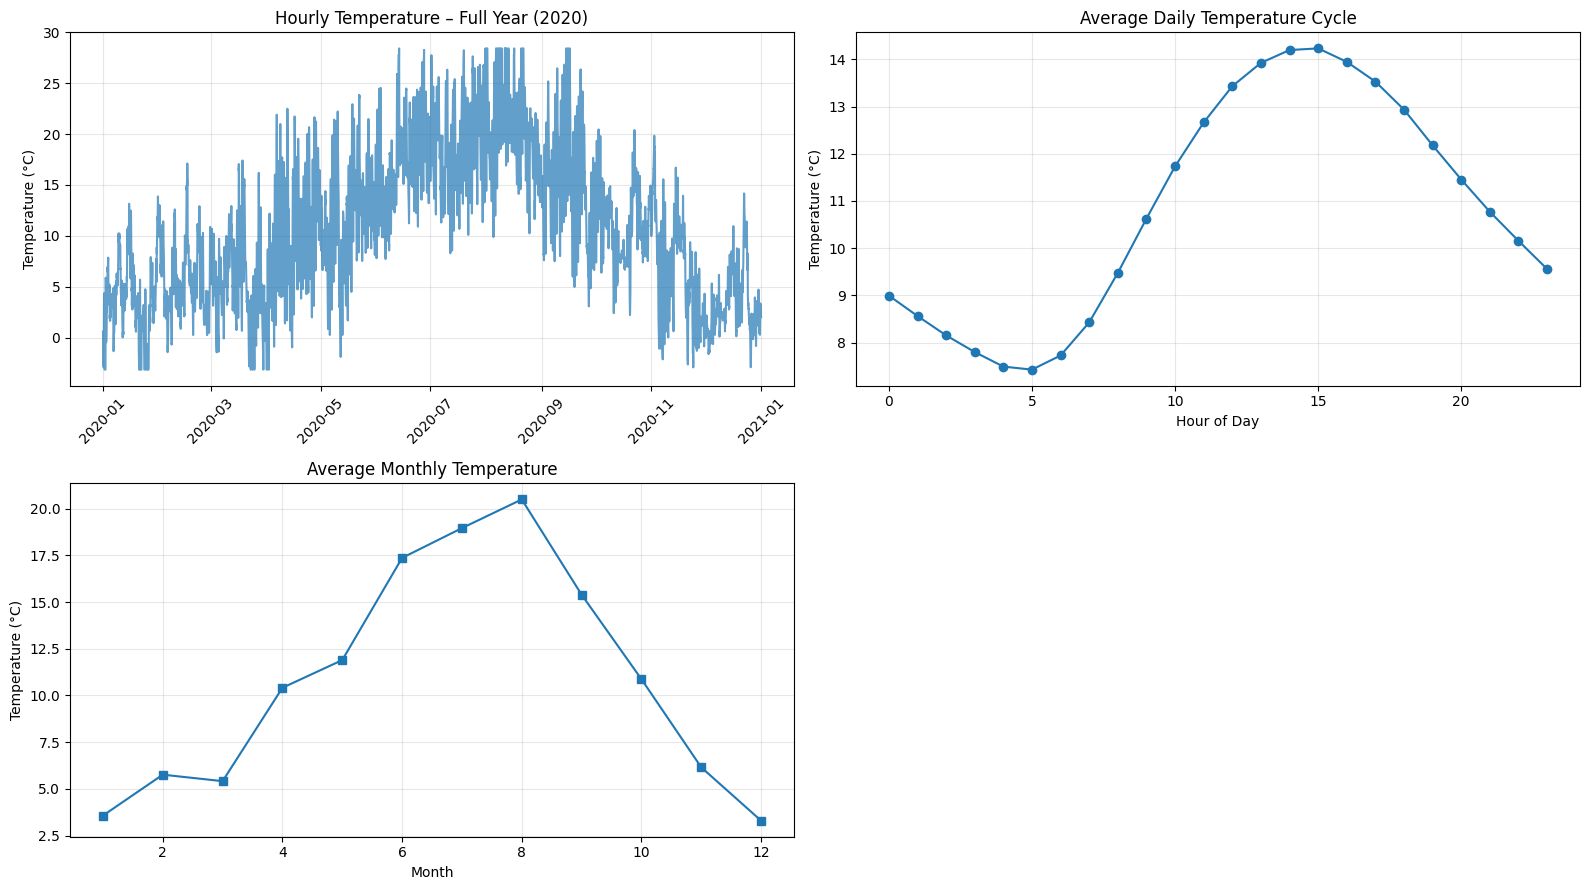

In [4]:
plt.figure(figsize=(16, 9))

# 2.1 Full year hourly temperature
plt.subplot(2, 2, 1)
plt.plot(df_temp["date"], df_temp["y"], alpha=0.7)
plt.title("Hourly Temperature – Full Year (2020)")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# 2.2 Average daily cycle
df_temp["hour"] = df_temp["date"].dt.hour
daily = df_temp.groupby("hour")["y"].mean()

plt.subplot(2, 2, 2)
plt.plot(daily.index, daily.values, marker="o")
plt.title("Average Daily Temperature Cycle")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)

# 2.3 Average monthly temperature
df_temp["month"] = df_temp["date"].dt.month
monthly = df_temp.groupby("month")["y"].mean()

plt.subplot(2, 2, 3)
plt.plot(monthly.index, monthly.values, marker="s")
plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure_1_temperature_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 3 – RMSE heatmap: all models vs horizons


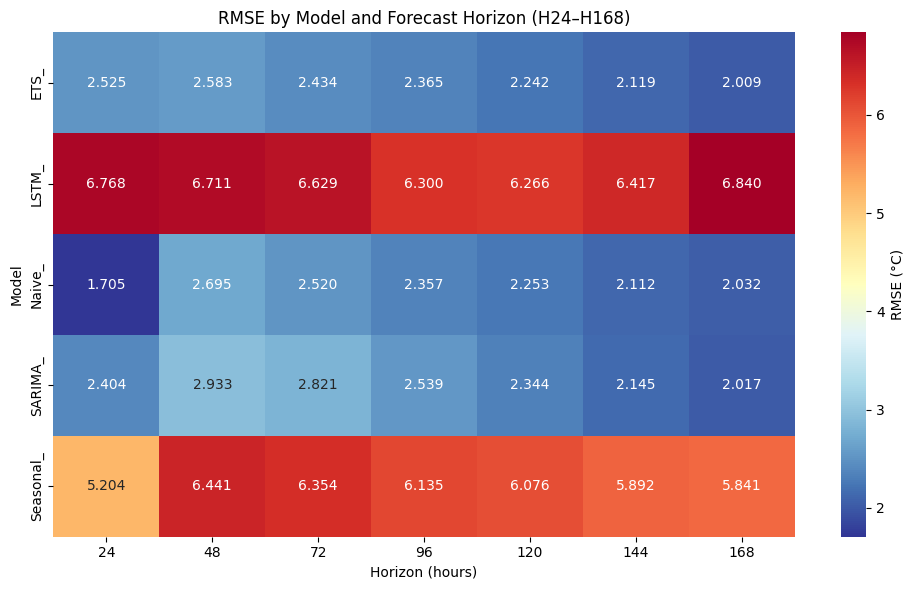

In [5]:
# m4_results index like: Naiveh24, Seasonalh48, SARIMAh72, ETSh168, LSTMh24, ...
tmp = m4_results.copy().reset_index()
tmp.columns = ["model_horizon", "MAE", "RMSE"]

# Split into Model and Horizon
tmp["Model"] = tmp["model_horizon"].str.split("h").str[0]
tmp["Horizon"] = tmp["model_horizon"].str.split("h").str[1].astype(int)

rmse_pivot = tmp.pivot(index="Model", columns="Horizon", values="RMSE")
rmse_pivot = rmse_pivot[sorted(rmse_pivot.columns)]

plt.figure(figsize=(10, 6))
sns.heatmap(rmse_pivot, annot=True, fmt=".3f", cmap="RdYlBu_r",
            cbar_kws={"label": "RMSE (°C)"})
plt.title("RMSE by Model and Forecast Horizon (H24–H168)")
plt.xlabel("Horizon (hours)")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("figure_2_model_rmse_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 4 – 48-hour forecast comparison (Naive / Seasonal / SARIMA / ETS / LSTM)

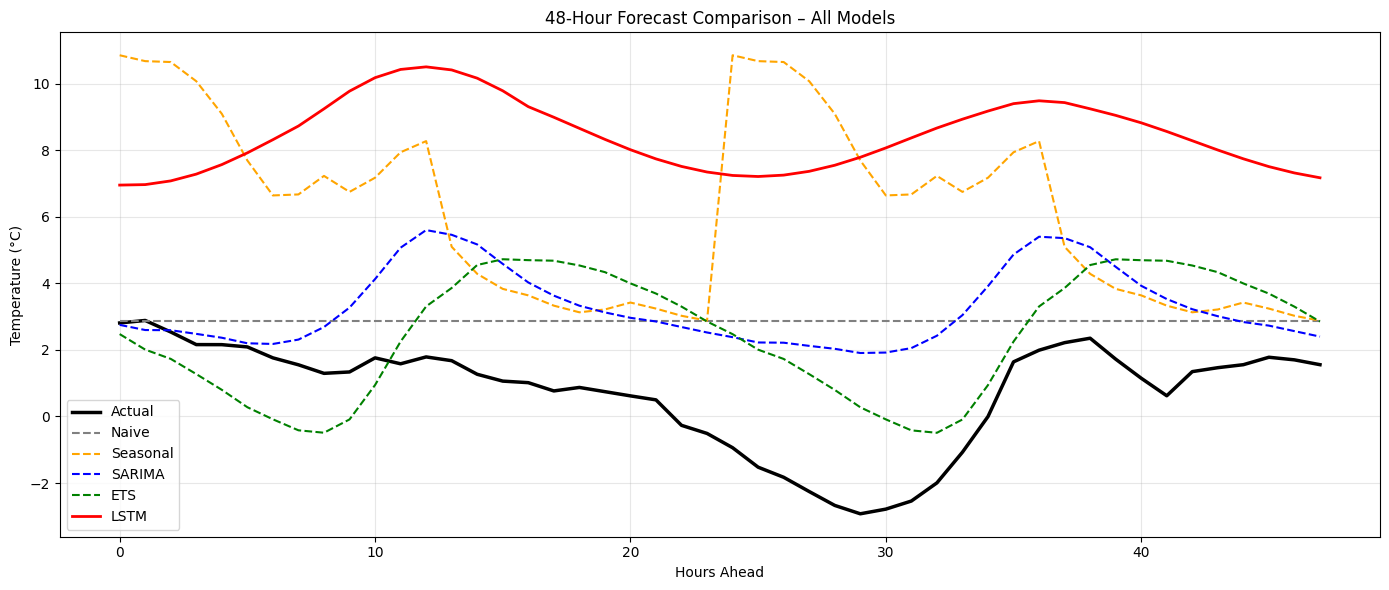

In [6]:
h = 48

plt.figure(figsize=(14, 6))
x = np.arange(h)

# Member 2 forecasts for test period (first 48 steps)
plt.plot(x, m2_forecasts["actual"].iloc[:h], "k-", linewidth=2.5, label="Actual")
plt.plot(x, m2_forecasts["naive"].iloc[:h], "gray", linestyle="--", label="Naive")
plt.plot(x, m2_forecasts["seasonal"].iloc[:h], "orange", linestyle="--", label="Seasonal")
plt.plot(x, m2_forecasts["sarima"].iloc[:h], "blue", linestyle="--", label="SARIMA")
plt.plot(x, m2_forecasts["ets"].iloc[:h], "green", linestyle="--", label="ETS")

# Member 3 LSTM 168h forecast: first 48 steps (same horizon length)
plt.plot(x, m3_forecasts["lstm"].iloc[:h], "red", linewidth=2, label="LSTM")

plt.title("48-Hour Forecast Comparison – All Models")
plt.xlabel("Hours Ahead")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_3_48h_forecast_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 5 – Executive summary table (Member 4 summary_table.csv)

In [7]:
print("EXECUTIVE SUMMARY TABLE (from Member 4):")
print(m4_summary.to_markdown(index=False))

# Save a copy with Member 5 prefix if needed
m4_summary.to_csv("05_summary_table_copy.csv", index=False)

EXECUTIVE SUMMARY TABLE (from Member 4):
| Horizon   | Best_Model   |   RMSE | Business_Use       |
|:----------|:-------------|-------:|:-------------------|
| H24       | Naive        |  1.705 | Daily planning     |
| H48       | ETS          |  2.583 | Weekly inventory   |
| H72       | ETS          |  2.434 | Medium-term        |
| H168      | ETS          |  2.009 | Strategic planning |


### Step 6 – Best model per horizon bar plot (from allmodelresults.csv)


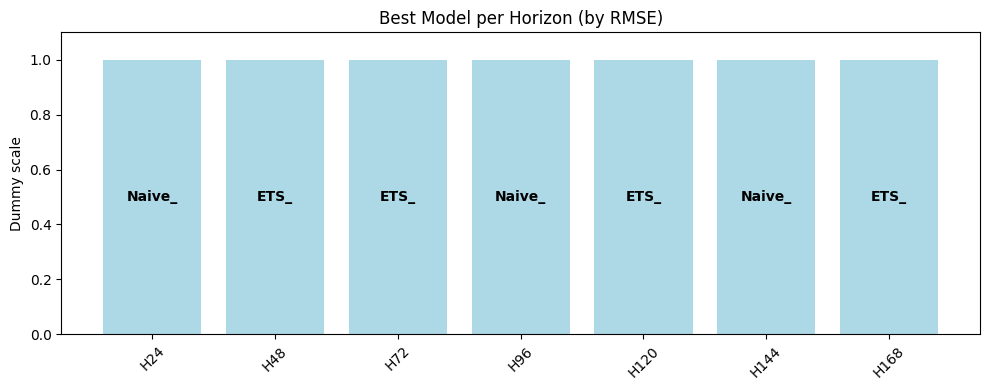

In [8]:
horizons = sorted(tmp["Horizon"].unique())
best_models = []

for h0 in horizons:
    hdata = tmp[tmp["Horizon"] == h0]
    if not hdata.empty:
        best_row = hdata.loc[hdata["RMSE"].idxmin()]
        best_models.append(best_row["Model"])

plt.figure(figsize=(10, 4))
plt.bar(range(len(horizons)), [1]*len(horizons), color="lightblue")
plt.xticks(range(len(horizons)), [f"H{h0}" for h0 in horizons], rotation=45)
for i, m in enumerate(best_models):
    plt.text(i, 0.5, m, ha="center", va="center", fontweight="bold", color="black")
plt.ylim(0, 1.1)
plt.title("Best Model per Horizon (by RMSE)")
plt.ylabel("Dummy scale")
plt.tight_layout()
plt.savefig("figure_4_best_model_per_horizon.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 7 – Final printout of created assets


In [9]:
print("\nFiles created for the report:")
print(" - figure_1_temperature_patterns.png")
print(" - figure_2_model_rmse_heatmap.png")
print(" - figure_3_48h_forecast_comparison.png")
print(" - figure_4_best_model_per_horizon.png")
print(" - 05_summary_table_copy.csv")


Files created for the report:
 - figure_1_temperature_patterns.png
 - figure_2_model_rmse_heatmap.png
 - figure_3_48h_forecast_comparison.png
 - figure_4_best_model_per_horizon.png
 - 05_summary_table_copy.csv
